#practising the concepts that we learnt - multi linear regression , where there are multiple dependent or x values

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [78]:
path = "/home/silvy_linux/Desktop/Internship/Datasets/Exam_Score_Prediction.csv"

read_score_dataset = pd.read_csv(path)

read_score_dataset.head(3)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3


In [79]:
read_score_dataset.isnull().sum() #no missing values

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [80]:
duplicates = read_score_dataset[read_score_dataset.duplicated()]
duplicates #no duplicates

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score


In [81]:
read_score_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  str    
 3   course            20000 non-null  str    
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  str    
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  str    
 9   study_method      20000 non-null  str    
 10  facility_rating   20000 non-null  str    
 11  exam_difficulty   20000 non-null  str    
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 2.0 MB


In [82]:
read_score_dataset['exam_difficulty'].value_counts()  #proceeed no need to handle imbalanced data

exam_difficulty
moderate    9878
easy        6141
hard        3981
Name: count, dtype: int64

In [83]:
label_encode = LabelEncoder()

In [84]:
#performing label encoding 

columns_to_label_encode = ['internet_access','sleep_quality','facility_rating','exam_difficulty']

for col in columns_to_label_encode:
    read_score_dataset[col] = label_encode.fit_transform(read_score_dataset[col])

print(read_score_dataset.head()) 

   student_id  age  gender   course  study_hours  class_attendance  \
0           1   17    male  diploma         2.78              92.9   
1           2   23   other      bca         3.37              64.8   
2           3   22    male     b.sc         7.88              76.8   
3           4   20   other  diploma         0.67              48.4   
4           5   20  female  diploma         0.89              71.6   

   internet_access  sleep_hours  sleep_quality   study_method  \
0                1          7.4              2       coaching   
1                1          4.6              0  online videos   
2                1          8.5              2       coaching   
3                1          5.8              0  online videos   
4                1          9.8              2       coaching   

   facility_rating  exam_difficulty  exam_score  
0                1                1        58.9  
1                2                2        54.8  
2                0                2   

In [85]:
# read_score_dataset['internet_access'] = read_score_dataset['internet_access'].map({
#     'Yes': 1,
#     'No': 0
# })    -> alernate way to perform ecoding where the user has control of what the data changes into

In [86]:
# Show mapping
mapping = dict(zip(label_encode.classes_,
                   label_encode.transform(label_encode.classes_)))

print(mapping)   #shows what the label encoder values mapped to 
#this is only shows the last one as the last run of the loop

{'easy': np.int64(0), 'hard': np.int64(1), 'moderate': np.int64(2)}


In [87]:
# from sklearn.preprocessing import LabelEncoder

# columns_to_label_encode = [
#     'internet_access',
#     'sleep_quality',
#     'facility_rating',
#     'exam_difficulty'
# ]

# for col in columns_to_label_encode:
    
#     le = LabelEncoder()
    
#     # Fit and transform
#     read_score_dataset[col] = le.fit_transform(read_score_dataset[col])

#     # Create mapping
#     mapping = dict(zip(
#         le.classes_,
#         le.transform(le.classes_)
#     ))

#     # Print mapping
#     print(f"{col} mapping:")
#     print(mapping)
#     print()

# print(read_score_dataset.head())   #for each column and print the mapping inside the loop.

In [88]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas')

In [89]:
ohetransform = ohe.fit_transform(read_score_dataset[["study_method"]])

In [90]:
ohetransform

,study_method_coaching,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
19995,0.0,0.0,0.0,0.0,1.0
19996,1.0,0.0,0.0,0.0,0.0
19997,0.0,1.0,0.0,0.0,0.0
19998,0.0,0.0,0.0,0.0,1.0


In [91]:
read_housing_data = pd.concat([read_score_dataset,ohetransform],axis='columns')

In [92]:
read_score_dataset

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,1,7.4,2,coaching,1,1,58.9
1,2,23,other,bca,3.37,64.8,1,4.6,0,online videos,2,2,54.8
2,3,22,male,b.sc,7.88,76.8,1,8.5,2,coaching,0,2,90.3
3,4,20,other,diploma,0.67,48.4,1,5.8,0,online videos,1,2,29.7
4,5,20,female,diploma,0.89,71.6,1,9.8,2,coaching,1,2,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,other,bba,6.50,71.3,1,5.0,1,self-study,1,0,86.5
19996,19998,18,male,b.com,3.71,41.6,0,5.9,0,coaching,2,2,60.9
19997,19999,19,other,diploma,7.88,68.2,1,4.6,2,group study,1,0,64.5
19998,20000,19,male,bba,4.60,76.3,0,6.1,1,self-study,2,2,79.0


In [93]:
read_score_dataset.drop(['study_method','gender','course','student_id'],axis='columns',inplace=True) #drop unwanted tables

In [94]:
read_score_dataset

,age,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty,exam_score
0,17,2.78,92.9,1,7.4,2,1,1,58.9
1,23,3.37,64.8,1,4.6,0,2,2,54.8
2,22,7.88,76.8,1,8.5,2,0,2,90.3
3,20,0.67,48.4,1,5.8,0,1,2,29.7
4,20,0.89,71.6,1,9.8,2,1,2,43.7
...,...,...,...,...,...,...,...,...,...
19995,18,6.50,71.3,1,5.0,1,1,0,86.5
19996,18,3.71,41.6,0,5.9,0,2,2,60.9
19997,19,7.88,68.2,1,4.6,2,1,0,64.5
19998,19,4.60,76.3,0,6.1,1,2,2,79.0


In [95]:
read_score_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   study_hours       20000 non-null  float64
 2   class_attendance  20000 non-null  float64
 3   internet_access   20000 non-null  int64  
 4   sleep_hours       20000 non-null  float64
 5   sleep_quality     20000 non-null  int64  
 6   facility_rating   20000 non-null  int64  
 7   exam_difficulty   20000 non-null  int64  
 8   exam_score        20000 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


## Performing multiple linear regression

In [100]:
x = read_score_dataset.drop('exam_score',axis=1)

In [101]:
y = read_score_dataset['exam_score']

In [102]:
x

,age,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty
0,17,2.78,92.9,1,7.4,2,1,1
1,23,3.37,64.8,1,4.6,0,2,2
2,22,7.88,76.8,1,8.5,2,0,2
3,20,0.67,48.4,1,5.8,0,1,2
4,20,0.89,71.6,1,9.8,2,1,2
...,...,...,...,...,...,...,...,...
19995,18,6.50,71.3,1,5.0,1,1,0
19996,18,3.71,41.6,0,5.9,0,2,2
19997,19,7.88,68.2,1,4.6,2,1,0
19998,19,4.60,76.3,0,6.1,1,2,2


In [103]:
y

0        58.9
1        54.8
2        90.3
3        29.7
4        43.7
         ... 
19995    86.5
19996    60.9
19997    64.5
19998    79.0
19999    71.0
Name: exam_score, Length: 20000, dtype: float64

In [104]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [105]:
print(x.shape,x_train.shape,x_test.shape)

(20000, 8) (16000, 8) (4000, 8)


In [106]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 16000 entries, 5894 to 15795
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               16000 non-null  int64  
 1   study_hours       16000 non-null  float64
 2   class_attendance  16000 non-null  float64
 3   internet_access   16000 non-null  int64  
 4   sleep_hours       16000 non-null  float64
 5   sleep_quality     16000 non-null  int64  
 6   facility_rating   16000 non-null  int64  
 7   exam_difficulty   16000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 1.1 MB


In [107]:
scalar = StandardScaler()

In [108]:
#fit and transform training data
x_train_scaled = scalar.fit_transform(x_train)

In [109]:
#Transform testing data
x_test_scaled = scalar.fit_transform(x_test)

In [110]:
#create model 
model = LinearRegression()

In [111]:
#Train Model 

model.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [112]:
#prediction

y_pred = model.predict(x_test_scaled)

In [113]:
#compare actual vs predicted 

comparison = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})

comparison.head(10)

,Actual,Predicted
10650,31.1,36.145950
2041,81.6,67.582754
8668,68.0,57.177619
1114,100.0,89.329086
13902,84.8,82.850767
11963,52.8,36.348236
11072,53.1,57.632455
3002,81.0,68.067162
19771,72.6,62.613347
8115,25.4,32.482053


In [114]:
#Evaluation Model 

mse = mean_squared_error(y_test,y_pred)

mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print(mse,mae,rmse,r2)

126.379310622574 9.095839371962388 11.241855301620546 0.6466861496568082


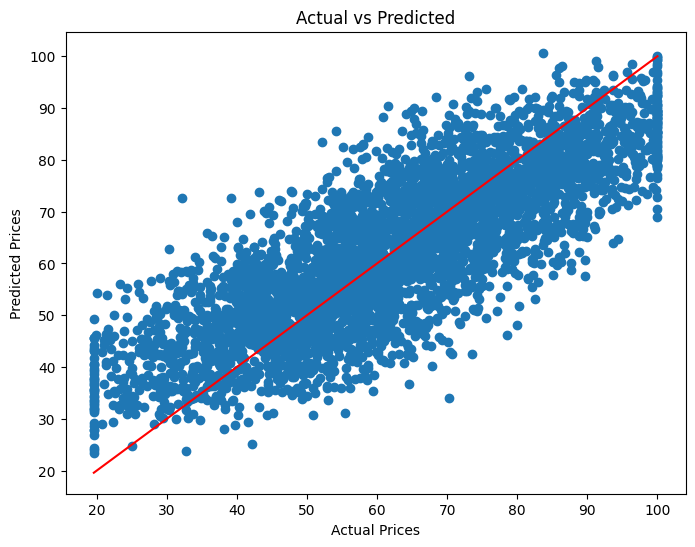

In [115]:
#Visualisation

plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = 'red'
)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")
plt.show()